##Walmart
stt742, sc68468

##Load Data

In [ ]:
import altair as alt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
storm = pd.read_csv('https://storage.googleapis.com/data-vis-open-access-p2/walmart/storm_data.csv')
distribution_centers = pd.read_csv('https://storage.googleapis.com/data-vis-open-access-p2/walmart/distribution_centers.csv')
store_network_lanes = pd.read_csv('https://storage.googleapis.com/data-vis-open-access-p2/walmart/store_network_lanes.csv')

In [ ]:
storm.head()

,Store_ID,Date,Product_Category,SKU_Name,Units_Sold,Avg_Daily_Sales,Inventory_On_Hand,Storm_Proximity,Lead_Time_Days
0,1001,2022-09-16,Grocery,Bottled Water (24pk),69,30,345,465,2.0
1,1014,2022-09-25,Household,Hand Sanitizer,15,15,115,7,10.1
2,1045,2022-09-07,Hardware,Plywood Sheet,31,12,151,185,2.0
3,1015,2022-09-02,Household,Hand Sanitizer,5,6,462,165,2.9
4,1018,2022-09-24,Hardware,Duct Tape,57,10,151,83,6.0


In [ ]:
distribution_centers.head()

,DC_ID,DC_Name,City,State,Latitude,Longitude
0,DC-ATL,Walmart SE Regional Hub,Atlanta,GA,33.7490,-84.3880
1,DC-JAX,Walmart Coastal Logistics,Jacksonville,FL,30.3322,-81.6557
2,DC-CLT,Walmart Carolinas Center,Charlotte,NC,35.2271,-80.8431


In [ ]:
store_network_lanes.head()

,Store_ID,City,State,Latitude,Longitude,Primary_DC_Link
0,1000,Savannah,GA,32.0809,-81.0912,DC-ATL
1,1001,Charleston,SC,32.7765,-79.9311,DC-CLT
2,1002,Miami,FL,25.7617,-80.1918,DC-JAX
3,1003,Orlando,FL,28.5383,-81.3792,DC-JAX
4,1004,Montgomery,AL,32.3668,-86.3000,DC-ATL


##Cleaning & Data intergration

In [ ]:
storm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Store_ID           3000 non-null   int64  
 1   Date               3000 non-null   object 
 2   Product_Category   3000 non-null   object 
 3   SKU_Name           3000 non-null   object 
 4   Units_Sold         3000 non-null   int64  
 5   Avg_Daily_Sales    3000 non-null   int64  
 6   Inventory_On_Hand  3000 non-null   int64  
 7   Storm_Proximity    3000 non-null   int64  
 8   Lead_Time_Days     3000 non-null   float64
dtypes: float64(1), int64(5), object(3)
memory usage: 211.1+ KB


In [ ]:
distribution_centers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   DC_ID      3 non-null      object 
 1   DC_Name    3 non-null      object 
 2   City       3 non-null      object 
 3   State      3 non-null      object 
 4   Latitude   3 non-null      float64
 5   Longitude  3 non-null      float64
dtypes: float64(2), object(4)
memory usage: 276.0+ bytes


In [ ]:
store_network_lanes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Store_ID         16 non-null     int64  
 1   City             16 non-null     object 
 2   State            16 non-null     object 
 3   Latitude         16 non-null     float64
 4   Longitude        16 non-null     float64
 5   Primary_DC_Link  16 non-null     object 
dtypes: float64(2), int64(1), object(3)
memory usage: 900.0+ bytes


**Transform data**

Remove duplicates from the data sets.

In [ ]:
storm.drop_duplicates(inplace=True)
distribution_centers.drop_duplicates(inplace=True)
store_network_lanes.drop_duplicates(inplace=True)

Reformat

In [ ]:
storm['Date'] = pd.to_datetime(storm['Date'])
storm['Store_ID'] = storm['Store_ID'].astype(str)
store_network_lanes['Store_ID'] = store_network_lanes['Store_ID'].astype(str)
store_network_lanes['Primary_DC_Link'] = store_network_lanes['Primary_DC_Link'].astype(str)
distribution_centers['DC_ID'] = distribution_centers['DC_ID'].astype(str)

**Merging**

We performed an inner join on Store_ID for "storm" and "store_network_lanes" data sets.

Keeping only the storeIDs that appear in both data sets would lead to dropping some stores that don't appear on network lanes, but this approach guarantees that every store in the final data has a verifiable geographic location and is built on an actionable foundation.  

In [ ]:
merged1 = pd.merge(storm, store_network_lanes, on='Store_ID', how='inner')

In [ ]:
merged1.head()

,Store_ID,Date,Product_Category,SKU_Name,Units_Sold,Avg_Daily_Sales,Inventory_On_Hand,Storm_Proximity,Lead_Time_Days,City,State,Latitude,Longitude,Primary_DC_Link
0,1001,2022-09-16,Grocery,Bottled Water (24pk),69,30,345,465,2.0,Charleston,SC,32.7765,-79.9311,DC-CLT
1,1014,2022-09-25,Household,Hand Sanitizer,15,15,115,7,10.1,Myrtle Beach,SC,33.6891,-78.8867,DC-CLT
2,1015,2022-09-02,Household,Hand Sanitizer,5,6,462,165,2.9,Columbus,GA,32.4610,-84.9877,DC-ATL
3,1015,2022-09-03,Hardware,Plywood Sheet,18,5,267,286,2.5,Columbus,GA,32.4610,-84.9877,DC-ATL
4,1004,2022-09-19,Grocery,Bottled Water (24pk),81,21,298,178,2.5,Montgomery,AL,32.3668,-86.3000,DC-ATL


We merged the previous dataset with the "distribution_centers" dataset using inner join. We used suffixes "_store" and "_dc" to differentiate between identical column names such as latitude, longitude, city, and state that exist in both the store and the distribution center datasets.

While this approach may penalizes our data by dropping any transaction that cannot be mapped to a verified supply chain route, this helped us calculate the precise geographic distance between each store and its resource, which is a critical feature for the logistic executives to evaluate how to reroute supply chain lanes in real-time.

In [ ]:
final = pd.merge(merged1, distribution_centers, left_on='Primary_DC_Link', right_on='DC_ID', how='inner', suffixes=('_store', '_dc'))

In [ ]:
final.head()

,Store_ID,Date,Product_Category,SKU_Name,Units_Sold,Avg_Daily_Sales,Inventory_On_Hand,Storm_Proximity,Lead_Time_Days,City_store,State_store,Latitude_store,Longitude_store,Primary_DC_Link,DC_ID,DC_Name,City_dc,State_dc,Latitude_dc,Longitude_dc
0,1001,2022-09-16,Grocery,Bottled Water (24pk),69,30,345,465,2.0,Charleston,SC,32.7765,-79.9311,DC-CLT,DC-CLT,Walmart Carolinas Center,Charlotte,NC,35.2271,-80.8431
1,1014,2022-09-25,Household,Hand Sanitizer,15,15,115,7,10.1,Myrtle Beach,SC,33.6891,-78.8867,DC-CLT,DC-CLT,Walmart Carolinas Center,Charlotte,NC,35.2271,-80.8431
2,1015,2022-09-02,Household,Hand Sanitizer,5,6,462,165,2.9,Columbus,GA,32.4610,-84.9877,DC-ATL,DC-ATL,Walmart SE Regional Hub,Atlanta,GA,33.7490,-84.3880
3,1015,2022-09-03,Hardware,Plywood Sheet,18,5,267,286,2.5,Columbus,GA,32.4610,-84.9877,DC-ATL,DC-ATL,Walmart SE Regional Hub,Atlanta,GA,33.7490,-84.3880
4,1004,2022-09-19,Grocery,Bottled Water (24pk),81,21,298,178,2.5,Montgomery,AL,32.3668,-86.3000,DC-ATL,DC-ATL,Walmart SE Regional Hub,Atlanta,GA,33.7490,-84.3880


In [ ]:
final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 905 entries, 0 to 904
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Store_ID           905 non-null    object        
 1   Date               905 non-null    datetime64[ns]
 2   Product_Category   905 non-null    object        
 3   SKU_Name           905 non-null    object        
 4   Units_Sold         905 non-null    int64         
 5   Avg_Daily_Sales    905 non-null    int64         
 6   Inventory_On_Hand  905 non-null    int64         
 7   Storm_Proximity    905 non-null    int64         
 8   Lead_Time_Days     905 non-null    float64       
 9   City_store         905 non-null    object        
 10  State_store        905 non-null    object        
 11  Latitude_store     905 non-null    float64       
 12  Longitude_store    905 non-null    float64       
 13  Primary_DC_Link    905 non-null    object        
 14  DC_ID     

##Feature Engineering

1. Demand Spike Ratio


In [ ]:
final['Demand_Spike_Ratio'] = final['Units_Sold'] / final['Avg_Daily_Sales'].replace(0, np.nan)

2. Flag for Surges

In [ ]:
final['Surge_Flag'] = (final['Demand_Spike_Ratio'] > 3).astype(int)

3. Extra demand for abnormal conditions

In [ ]:
final['Units_Above_Baseline'] = final['Units_Sold'] - final['Avg_Daily_Sales']

4. Normalized demand percentage increase

In [ ]:
final['Pct_Above_Baseline'] = ((final['Units_Sold'] - final['Avg_Daily_Sales']) / final['Avg_Daily_Sales']) * 100

5. Normal sales days inventory can support

In [ ]:
final['Inventory_Coverage_Days'] = final['Inventory_On_Hand'] / final['Avg_Daily_Sales']

6. Shortage or Excess Inventory relative to currently observed demand

In [ ]:
final['Inventory_Gap'] = final['Inventory_On_Hand'] - final['Units_Sold']

7. Check to see if demand exceeds inventory on hand

In [ ]:
final['Stockout_Flag'] = (final['Inventory_Gap'] < 0).astype(int)

8. Lead-time risk score

In [ ]:
final['Lead_Time_Risk'] = final['Lead_Time_Days'] - final['Inventory_Coverage_Days']

9. Storm urgency check, the closer the storm the higher the value will be

In [ ]:
final['Storm_Urgency'] = 1 / (final['Storm_Proximity'] + 1)

10. Priority score: combines storm closeness, abnormal demand, and replenishment risk

In [ ]:
final['Priority_Score'] = (final['Demand_Spike_Ratio'] * final['Storm_Urgency'] * final['Lead_Time_Risk'].clip(lower=0))

11. Timeline

In [ ]:
timeline = final.groupby('Date').agg({
    'Inventory_On_Hand': 'sum',
    'Units_Sold': 'sum',
    'Storm_Proximity': 'mean'
}).reset_index()
timeline['Date'] = pd.to_datetime(timeline['Date'])

##Predictive Demand Heat Maps

1. Anticipated stock depletions

This reveals that stock depletions (Red circles) are not random, they are  clustered along specific coastal corridors where storm proximity is under 100 miles.


In [ ]:
import altair as alt
from vega_datasets import data

states = alt.topo_feature(data.us_10m.url, 'states')

background = alt.Chart(states).mark_geoshape(fill='lightgray',
    stroke='white',
    strokeWidth=1)

points = alt.Chart(final).mark_circle(opacity=0.7, stroke='black').encode(longitude='Longitude_store:Q',
    latitude='Latitude_store:Q',
    size=alt.Size('Priority_Score:Q', scale=alt.Scale(range=[50, 2000])),
    color=alt.Color('Inventory_Gap:Q', scale=alt.Scale(scheme='redyellowgreen', domainMid=0)),
    tooltip=['City_store:N', 'Inventory_Gap:Q'])

#distribution centers as diamond shapes
dc = alt.Chart(final).mark_point(shape='diamond', size=300, color='black', fill='black').encode(
    longitude='Longitude_dc:Q',
    latitude='Latitude_dc:Q',
    tooltip=['DC_Name:N'])

final_chart = (background + points + dc).project(
    type='mercator',
    scale=900,
    center=[-96, 37.5]).properties(width=800,
    height=500,
    title='Anticipated Stock Depletions')

final_chart.interactive()


alt.LayerChart(...)

2. Network depletion vs storm proximity by period

The network suffers from a high stock depletion approximately 48 hours before landfall. Even as the storm is still distant, the anticipation causes a demand spike that the current restocking pace cannot match.

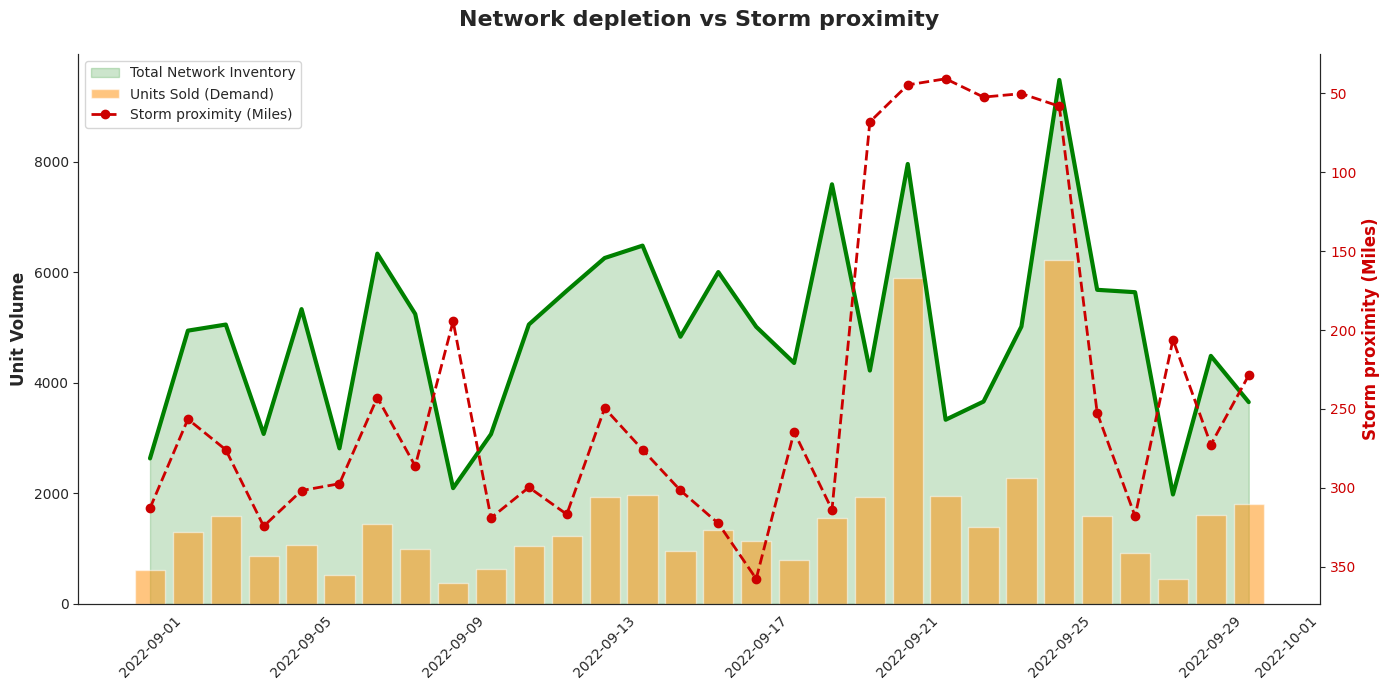

In [ ]:

sns.set_style("white")
fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.fill_between(timeline['Date'], timeline['Inventory_On_Hand'], color='green', alpha=0.2, label='Total Network Inventory')
ax1.plot(timeline['Date'], timeline['Inventory_On_Hand'], color='green', linewidth=3)
ax1.bar(timeline['Date'], timeline['Units_Sold'], color='#FF8C00', alpha=0.5, label='Units Sold (Demand)')
ax1.set_ylabel('Unit Volume', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(timeline['Date'], timeline['Storm_Proximity'], color='#CC0000', linestyle='--', linewidth=2, marker='o', label='Storm proximity (Miles)')
ax2.set_ylabel('Storm proximity (Miles)', color='#CC0000', fontsize=12, fontweight='bold')
ax2.invert_yaxis()
ax2.tick_params(axis='y', labelcolor='#CC0000', labelsize=10)

plt.title('Network depletion vs Storm proximity', fontsize=16, fontweight='bold', pad=20)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, fontsize=10)

sns.despine(right=False)
plt.tight_layout()
plt.show()

3. Combined Anticipated stock depletions and Network depletion vs storm proximity by period charts.

By dragging the slider, we can pinpoint the exact day the first green (stable) circle turns red (critical).

This simulation identifies a 48-hour critical window where network demand outstrips local supply. By mapping the panic radius around coastal clusters, this model shows that certain distribution centers are surrounded by a high density of "Large Priority" circles, while others remain in "Green" zones.

This can help identify which center is going to be under the most operational stress, therefore suggesting a rerouting opportunity (such as moving inventory between green (under-utilized) and red circles (overwhelmed) to balance the network load). This also allows us to ensure that critical items are in-store before the storm severs the primary logistics lanes.

In [29]:
import folium
from folium.plugins import TimestampedGeoJson

m = folium.Map(location=[31.5, -83.0], zoom_start=6, tiles='CartoDB positron')

#geojson
features = []

for idx, row in final.iterrows():
    #Red if out of stock, green if otherwise
    color = '#FF0000' if row['Stockout_Flag'] == 1 else '#00FF00'

    # circles radius based on priorities
    radius = 5 + (row['Priority_Score'])

    feature = {'type': 'Feature',
        'geometry': {'type': 'Point',
            'coordinates': [row['Longitude_store'], row['Latitude_store']],},
        'properties': {'time': row['Date'].strftime('%Y-%m-%dT%H:%M:%S'),
            'style': {'color': color,
                'fillColor': color,
                'fillOpacity': 0.4,
                'radius': radius,
                'weight': 1},
            'icon': 'circle',
            'popup': f"""
                <b>Store: {row['City_store']}</b><br>
                <b>Date: {row['Date'].strftime('%Y-%m-%d')}</b><br>
                Status: {'CRITICAL' if row['Stockout_Flag'] == 1 else 'Stable'}<br>
                Inventory Gap: {row['Inventory_Gap']} units<br>
                Storm Proximity: {row['Storm_Proximity']} miles
            """}}
    features.append(feature)

#Distribution centers as black star signs
for dc_idx, dc_row in distribution_centers.iterrows():
    folium.Marker(location=[dc_row['Latitude'], dc_row['Longitude']],
        icon=folium.Icon(color='black', icon='star'),
        tooltip=f"DC: {dc_row['DC_Name']}").add_to(m)

TimestampedGeoJson({'type': 'FeatureCollection', 'features': features},
    period='P1D',
    add_last_point=True,
    auto_play=False,
    loop=False,
    max_speed=1,
    loop_button=True,
    date_options='YYYY-MM-DD',
    time_slider_drag_update=True).add_to(m)

m

Product Coorelation Chart

This chart highlights the products that experience the most significant demand spikes during storm events. It shows that demand surges are highly concentrated among a small subset of products, with the top three products showing having a disproportionately higher spike ratio when compared to the rest. This indicates that consumer purchases during storms are not evenly distributed, but instead focused on essential goods.

In [ ]:
top3 = top_skus.nlargest(3, 'Demand_Spike_Ratio')['SKU_Name'].tolist()
sku_chart = alt.Chart(top_skus).mark_bar().encode(
    x=alt.X('Demand_Spike_Ratio:Q', title='Average Demand Spike Ratio'),
    y=alt.Y('SKU_Name:N', sort='-x', title='Product'),
    color=alt.condition(
        alt.FieldOneOfPredicate(field='SKU_Name', oneOf=top3),
        alt.value('#b22222'),   # highlight color (dark red)
        alt.value('lightgray')  # muted baseline
    ),
    tooltip=[
        alt.Tooltip('SKU_Name:N', title='Product'),
        alt.Tooltip('Demand_Spike_Ratio:Q', title='Avg Spike', format='.2f')
    ]
).properties(
    width=700,
    height=400,
    title='Products Driving the Largest Storm Demand Surges'
)
sku_chart

alt.Chart(...)

DC Prioritization Chart

This chart ranks distribution centers based on the average priority score of the stores they support, highlighting where supply chain pressure is most concentrated. It shows that one distribution center has a significantly higher priority score than the others, indicating that it supplies a disproportionate number of high-risk, high-demand stores. This suggests that supply chain stress is not evenly distributed across the network, but instead concentrated within specific center. This concentration creates a potential bottleneck, where a single distribution center may become overwhelmed as demand surges and inventory depletes across its associated stores.

In [27]:
top_dc = dc_priority.nlargest(1, 'Priority_Score')['DC_Name'].iloc[0]
dc_chart = alt.Chart(dc_priority).mark_bar().encode(
    x=alt.X('Priority_Score:Q', title='Average Priority Score'),
    y=alt.Y('DC_Name:N', sort='-x', title='Distribution Center'),
    color=alt.condition(
        alt.datum.DC_Name == top_dc,
        alt.value('#b22222'),   # highlight top DC
        alt.value('lightgray')  # others
    ),
    tooltip=[
        alt.Tooltip('DC_ID:N', title='DC ID'),
        alt.Tooltip('DC_Name:N', title='DC Name'),
        alt.Tooltip('Priority_Score:Q', title='Avg Priority', format='.2f')
    ]
).properties(
    width=700,
    height=350,
    title='Distribution Center Facing the Highest Supply Chain Pressures'
)
dc_chart

alt.Chart(...)

Risk Chart

This chart compares how long inventory will last vs. how long it takes to recover it, showing where stockout risk is the highest.
The points represent store-product combinations, and the red markers indicate instances where lead time exceeds available inventory coverage. These scenarios represent zones with the highest where demand cannot be met until the next cycle. The cluster of red points shows that this mismatch occurs across multiple locations and products, particularly in high-demand environments. This indicates that current replenishment timelines are not enough to support surges conditions during storms.

In [28]:
risk_chart = alt.Chart(final).mark_circle(size=85, opacity=0.75).encode(
    x=alt.X('Inventory_Coverage_Days:Q', title='Inventory Coverage (Days)'),
    y=alt.Y('Lead_Time_Days:Q', title='Lead Time (Days)'),
    color=alt.condition(
        alt.datum.Lead_Time_Risk > 0,
        alt.value('#b22222'),
        alt.value('gray')
    ),
    tooltip=[
        alt.Tooltip('Store_ID:N', title='Store ID'),
        alt.Tooltip('City_store:N', title='City'),
        alt.Tooltip('SKU_Name:N', title='SKU'),
        alt.Tooltip('Inventory_Coverage_Days:Q', title='Coverage Days', format='.2f'),
        alt.Tooltip('Lead_Time_Days:Q', title='Lead Time', format='.2f'),
        alt.Tooltip('Lead_Time_Risk:Q', title='Risk', format='.2f')
    ]
).properties(
    width=700,
    height=450,
    title='Inventory Coverage v. Lead Time Representing Stockout Risk'
)
risk_chart

alt.Chart(...)